Mashalov Rasulbek, OSTC2U, Machine Learning, HomeWork 4, 5th March, 2026.

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

housing = fetch_california_housing()

X = pd.DataFrame(housing.data, columns=housing.feature_names)
Y = pd.DataFrame(housing.target)

print(housing.DESCR)      #get a description of the dataset
print(housing.data.shape) #get (numer of rows, number of columns or 'features')
print(housing.target_names)
print(f"[INFO] X shape: {X.shape}, Y shape: {Y.shape}")

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

**EXERCISE 1**

In [37]:
print("[INFO] constructing training/testing sets")
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=2021)
lm = LinearRegression()
lm.fit(x_train, y_train)

y_pred = lm.predict(x_test)

print("[INFO] Base model trained and predictions generated!")

[INFO] constructing training/testing sets
[INFO] Base model trained and predictions generated!


In [38]:
sklearn_loss = mean_squared_error(y_test, y_pred)

print(f"[INFO] Scikit-Learn MSE: {sklearn_loss:.2f}")


[INFO] Scikit-Learn MSE: 0.52


**EXERCISE 2**

In [39]:
#initializing rigid regression with alfa=0.001
ridge_model = Ridge(alpha=0.001)

#training model
ridge_model.fit(x_train, y_train)

#predictions
y_pred_ridge = ridge_model.predict(x_test)

#calculating&printing the loss
ridge_loss = mean_squared_error(y_test, y_pred_ridge)
print(f"[INFO] Ridge Regression (alpha=0.001) \nLoss: {ridge_loss:.2f}")

[INFO] Ridge Regression (alpha=0.001) 
Loss: 0.52


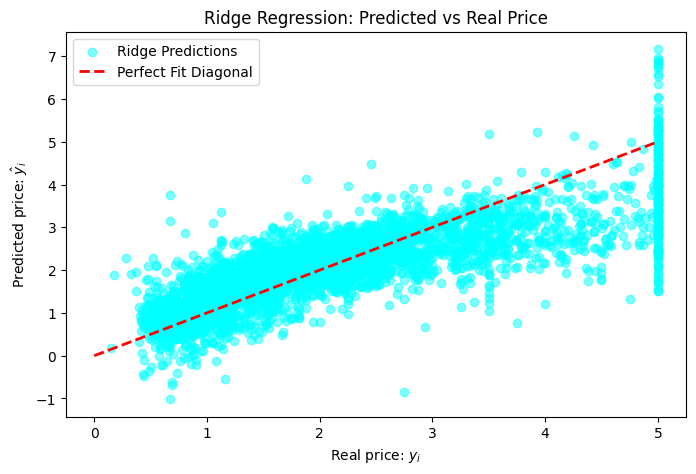

In [40]:
#visualization
plt.figure(figsize=(8, 5))

#ploting the actual predictions (Real vs Predicted)
plt.scatter(y_test, y_pred_ridge, color='cyan', alpha=0.5, label='Ridge Predictions')

#drawing "Perfect Prediction" diagonal line
plt.plot([0, 5], [0, 5], color='red', linestyle='--', linewidth=2, label='Perfect Fit Diagonal')

#labeling
plt.xlabel("Real price: $y_i$")
plt.ylabel("Predicted price: $\\hat{y}_i$")
plt.title("Ridge Regression: Predicted vs Real Price")
plt.legend()

plt.show()

**EXRECISE 3**

In [41]:
#initializing Lasso regression with alfa=0.0001
lasso_model = Lasso(alpha=0.0001)

#training the model
lasso_model.fit(x_train, y_train)

#predictions
y_pred_lasso = lasso_model.predict(x_test)

#calculating&printing the loss
lasso_loss = mean_squared_error(y_test, y_pred_lasso)
print(f"[INFO] Lasso Regression (alpha=0.0001) \nLoss: {lasso_loss:.2f}")

[INFO] Lasso Regression (alpha=0.0001) 
Loss: 0.52


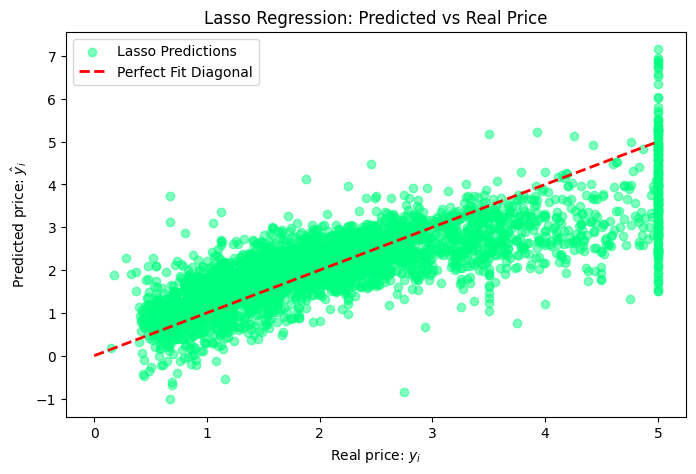

In [42]:
plt.figure(figsize=(8, 5))

#ploting the actual predictions (Real vs Predicted)
plt.scatter(y_test, y_pred_lasso, color='springgreen', alpha=0.5, label='Lasso Predictions')

#drawing "Perfect Prediction" diagonal line
plt.plot([0, 5], [0, 5], color='red', linestyle='--', linewidth=2, label='Perfect Fit Diagonal')

#labeling
plt.xlabel("Real price: $y_i$")
plt.ylabel("Predicted price: $\\hat{y}_i$")
plt.title("Lasso Regression: Predicted vs Real Price")
plt.legend()

plt.show()

**EXERCISE 4**

[INFO] Training polynomial models...
[INFO] Model with degree 4 trained successfully.
[INFO] Model with degree 5 trained successfully.
[INFO] Model with degree 6 trained successfully.
[INFO] Model with degree 7 trained successfully.
[INFO] Model with degree 8 trained successfully.
[INFO] Model with degree 9 trained successfully.


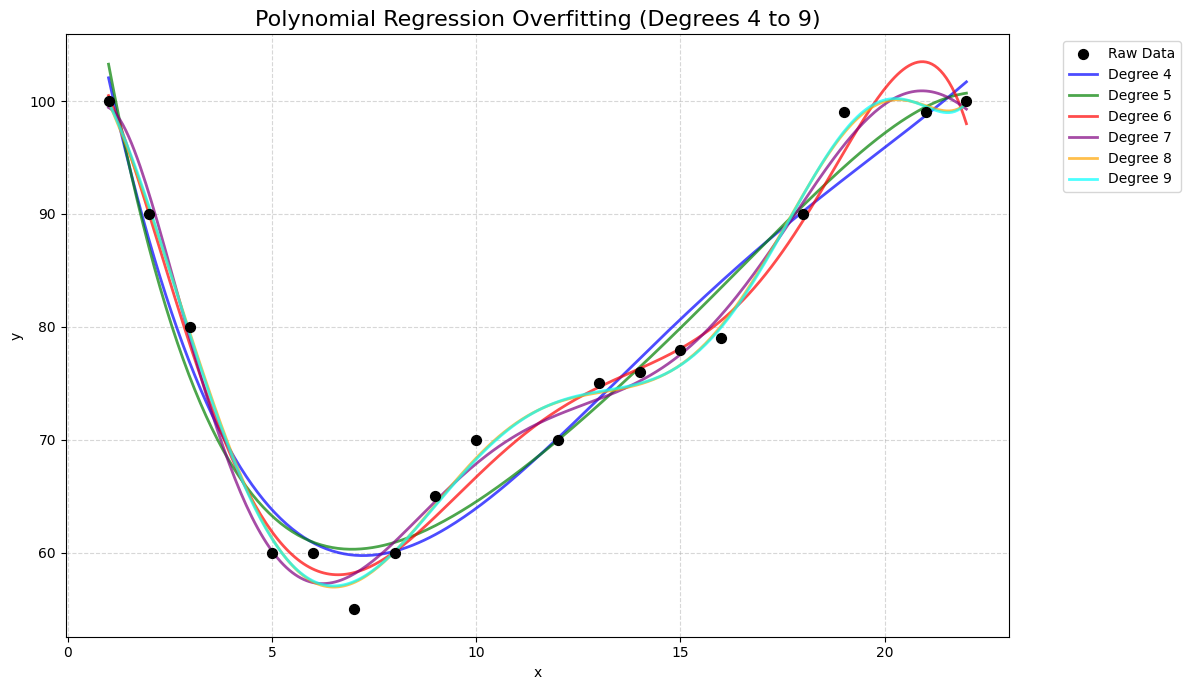

In [43]:
#toy dataset & reshaping it
x_toy = np.asarray([1,2,3,5,6,7,8,9,10,12,13,14,15,16,18,19,21,22]).reshape(-1, 1)
y_toy = np.asarray([100,90,80,60,60,55,60,65,70,70,75,76,78,79,90,99,99,100])

#setting up main canvas
plt.figure(figsize=(12, 7))
plt.title("Polynomial Regression Overfitting (Degrees 4 to 9)", size=16)
plt.xlabel("x")
plt.ylabel("y")

#plotting raw data points as black dots
plt.scatter(x_toy, y_toy, color="black", s=50, zorder=10, label="Raw Data")

#list of colors
colors = ['blue', 'green', 'red', 'purple', 'orange', 'cyan']

x_smooth = np.linspace(x_toy.min(), x_toy.max(), 300).reshape(-1, 1)

print("[INFO] Training polynomial models...")

#loopping through 4, 5, 6, 7, 8, and 9
for degree, color in zip(range(4, 10), colors):
    #transforming both training data AND our smooth plotting data
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    x_toy_poly = poly.fit_transform(x_toy)
    x_smooth_poly = poly.transform(x_smooth)

    #training model
    model = LinearRegression()
    model.fit(x_toy_poly, y_toy)

    #predicting using the smooth x-values
    y_pred_smooth = model.predict(x_smooth_poly)

    #drawing the curve on the chart
    plt.plot(x_smooth, y_pred_smooth, color=color, linewidth=2, alpha=0.7, label=f'Degree {degree}')
    print(f"[INFO] Model with degree {degree} trained successfully.")

#legend set up
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()